In [1]:
import json
import pandas as pd
import numpy as np

from scipy.sparse import hstack

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
with open("train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open("test.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

train_df.head()

Training data shape: (4040, 32)
Test data shape: (1631, 17)


,giver_username_if_known,number_of_downvotes_of_request_at_retrieval,number_of_upvotes_of_request_at_retrieval,post_was_edited,request_id,request_number_of_comments_at_retrieval,request_text,request_text_edit_aware,request_title,requester_account_age_in_days_at_request,...,requester_received_pizza,requester_subreddits_at_request,requester_upvotes_minus_downvotes_at_request,requester_upvotes_minus_downvotes_at_retrieval,requester_upvotes_plus_downvotes_at_request,requester_upvotes_plus_downvotes_at_retrieval,requester_user_flair,requester_username,unix_timestamp_of_request,unix_timestamp_of_request_utc
0,N/A,0,1,False,t3_l25d7,0,Hi I am in need of food for my 4 children we a...,Hi I am in need of food for my 4 children we a...,Request Colorado Springs Help Us Please,0.000000,...,False,[],0,1,0,1,None,nickylvst,1.317853e+09,1.317849e+09
1,N/A,2,5,False,t3_rcb83,0,I spent the last money I had on gas today. Im ...,I spent the last money I had on gas today. Im ...,"[Request] California, No cash and I could use ...",501.111100,...,False,"[AskReddit, Eve, IAmA, MontereyBay, RandomKind...",34,4258,116,11168,None,fohacidal,1.332652e+09,1.332649e+09
2,N/A,0,3,False,t3_lpu5j,0,My girlfriend decided it would be a good idea ...,My girlfriend decided it would be a good idea ...,"[Request] Hungry couple in Dundee, Scotland wo...",0.000000,...,False,[],0,3,0,3,None,jacquibatman7,1.319650e+09,1.319646e+09
3,N/A,0,1,True,t3_mxvj3,4,"It's cold, I'n hungry, and to be completely ho...","It's cold, I'n hungry, and to be completely ho...","[Request] In Canada (Ontario), just got home f...",6.518438,...,False,"[AskReddit, DJs, IAmA, Random_Acts_Of_Pizza]",54,59,76,81,None,4on_the_floor,1.322855e+09,1.322855e+09
4,N/A,6,6,False,t3_1i6486,5,hey guys:\n I love this sub. I think it's grea...,hey guys:\n I love this sub. I think it's grea...,[Request] Old friend coming to visit. Would LO...,162.063252,...,False,"[GayBrosWeightLoss, RandomActsOfCookies, Rando...",1121,1225,1733,1887,None,Futuredogwalker,1.373658e+09,1.373654e+09


In [3]:
train_df["combined_text"] = (
    train_df["request_title"].fillna("") + " " +
    train_df["request_text_edit_aware"].fillna("")
)

test_df["combined_text"] = (
    test_df["request_title"].fillna("") + " " +
    test_df["request_text_edit_aware"].fillna("")
)

In [4]:
target = "requester_received_pizza"

numeric_features = [
    "requester_account_age_in_days_at_request",
    "requester_days_since_first_post_on_raop_at_request",
    "requester_number_of_comments_at_request",
    "requester_number_of_comments_in_raop_at_request",
    "requester_number_of_posts_at_request",
    "requester_number_of_posts_on_raop_at_request",
    "requester_number_of_subreddits_at_request",
    "requester_upvotes_minus_downvotes_at_request",
    "requester_upvotes_plus_downvotes_at_request"
]

text_feature = "combined_text"

X_text = train_df[text_feature].fillna("")
X_num = train_df[numeric_features].fillna(0)
y = train_df[target].astype(int)

X_test_text = test_df[text_feature].fillna("")
X_test_num = test_df[numeric_features].fillna(0)

print("Label distribution:")
print(y.value_counts())

Label distribution:
requester_received_pizza
0    3046
1     994
Name: count, dtype: int64


In [5]:
X_text_train, X_text_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_text,
    X_num,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(y_train))
print("Validation rows:", len(y_val))

Training rows: 3232
Validation rows: 808


In [6]:
tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_val_tfidf = tfidf.transform(X_text_val)
X_test_text_tfidf = tfidf.transform(X_test_text)

print("TF-IDF training shape:", X_text_train_tfidf.shape)

TF-IDF training shape: (3232, 3000)


In [7]:
scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_val_scaled = scaler.transform(X_num_val)
X_test_num_scaled = scaler.transform(X_test_num)

In [8]:
X_train_final = hstack([X_text_train_tfidf, X_num_train_scaled]).toarray()
X_val_final = hstack([X_text_val_tfidf, X_num_val_scaled]).toarray()
X_test_final = hstack([X_test_text_tfidf, X_test_num_scaled]).toarray()

print("Final training shape:", X_train_final.shape)
print("Final validation shape:", X_val_final.shape)
print("Final test shape:", X_test_final.shape)

Final training shape: (3232, 3009)
Final validation shape: (808, 3009)
Final test shape: (1631, 3009)


In [9]:
input_dim = X_train_final.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       385,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,649 (1.51 MB)

 Trainable params: 395,649 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_final,
    y_train,
    validation_data=(X_val_final, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7491 - auc: 0.5339 - loss: 0.5750 - val_accuracy: 0.7550 - val_auc: 0.5572 - val_loss: 0.5578
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7658 - auc: 0.7116 - loss: 0.5081 - val_accuracy: 0.7488 - val_auc: 0.5789 - val_loss: 0.5545
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7992 - auc: 0.8468 - loss: 0.4165 - val_accuracy: 0.7228 - val_auc: 0.5787 - val_loss: 0.6419
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8899 - auc: 0.9430 - loss: 0.2702 - val_accuracy: 0.7104 - val_auc: 0.5989 - val_loss: 0.8124
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9610 - auc: 0.9872 - loss: 0.1251 - val_accuracy: 0.7017 - val_auc: 0.5935 - val_loss: 1.1300
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9833 - auc: 0.9967 - loss: 0.0595 - val_accuracy: 0.6621 - val_auc: 0.5932 - val_loss: 1.3214
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━

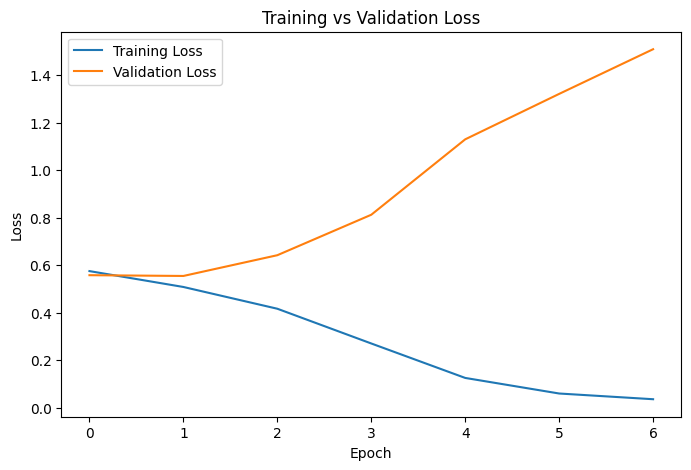

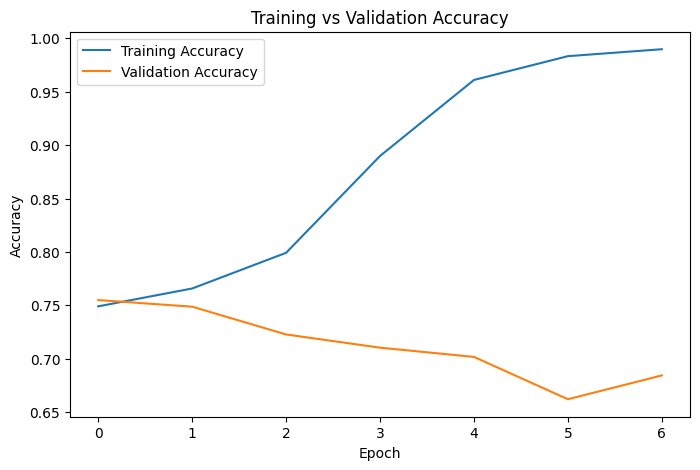

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [12]:
val_probabilities = model.predict(X_val_final).ravel()
val_predictions = (val_probabilities >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_val, val_predictions))
print("ROC-AUC:", roc_auc_score(y_val, val_probabilities))

print("\nClassification Report:")
print(classification_report(y_val, val_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_predictions))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy: 0.7487623762376238
ROC-AUC: 0.5797295178684886

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.98      0.85       609
           1       0.39      0.04      0.06       199

    accuracy                           0.75       808
   macro avg       0.57      0.51      0.46       808
weighted avg       0.67      0.75      0.66       808


Confusion Matrix:
[[598  11]
 [192   7]]


In [13]:
validation_results = pd.DataFrame({
    "actual": y_val.values,
    "predicted": val_predictions,
    "probability_received_pizza": val_probabilities
})

validation_results.head(10)

,actual,predicted,probability_received_pizza
0,0,0,0.158709
1,0,0,0.235399
2,1,0,0.216689
3,0,0,0.116592
4,0,0,0.343986
5,0,0,0.227585
6,0,0,0.161744
7,0,0,0.220938
8,0,0,0.228816
9,0,0,0.228084


In [14]:
test_probabilities = model.predict(X_test_final).ravel()
test_predictions = (test_probabilities >= 0.5).astype(int)

submission_df = pd.DataFrame({
    "request_id": test_df["request_id"],
    "requester_received_pizza_prediction": test_predictions,
    "probability_received_pizza": test_probabilities
})

submission_df.head()

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


,request_id,requester_received_pizza_prediction,probability_received_pizza
0,t3_i8iy4,0,0.288670
1,t3_1mfqi0,0,0.188939
2,t3_lclka,0,0.269983
3,t3_1jdgdj,0,0.187708
4,t3_t2qt4,0,0.216541


In [15]:
submission_df.to_csv("keras_mlp_pizza_predictions.csv", index=False)

print("Saved predictions to keras_mlp_pizza_predictions.csv")

Saved predictions to keras_mlp_pizza_predictions.csv
